# ChromSeek Multi-Omics Prediction Workflow

This notebook follows the ChromSeek enhancement app pattern for predicting 1 kb-resolution genomic tracks from DNA sequence and Hi-C. It uses the bundled example window and transfer checkpoint by default:

1. Configure the sample, checkpoint, cell type, and tracks.
2. Load and prepare the 2.24 Mb DNA/Hi-C window.
3. Run the pretrained multi-omics predictor.
4. Visualize predicted signal tracks against the example labels.

In [9]:
# ==========================================
# 1. Configuration & Setup
# ==========================================
from pathlib import Path

for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (PROJECT_ROOT / 'hic_enhancement').is_dir() and (PROJECT_ROOT / 'downstreams').is_dir():
        break
else:
    raise FileNotFoundError('Could not locate the ChromSeek project root.')
TASK_DIR = PROJECT_ROOT / 'downstreams' / 'multiomics_prediction'

DATA_PATH = TASK_DIR / 'sample_data.pt'
CKPT_PATH = PROJECT_ROOT / 'checkpoints' / 'transfer_multiomics_best.pth'
# The sample was generated for GM12878. Set this to GM12878 or K562 for a checkpoint-supported cell.
CELL_NAME = 'GM12878'
TRACKS_TO_PLOT = None  # None plots every track; or provide e.g. ['CTCF', 'ATAC', 'MYC'].
OVERVIEW_EXCLUDED_TRACKS = {'H3K79me2', 'H3K9me3', 'H3K27me3', 'H3K4me1'}
SMOOTH_WINDOW = 10  # 1 kb bins used for display smoothing; set to 1 to disable.
DISPLAY_START_BIN = 300
DISPLAY_END_BIN = 2240

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Sample data not found: {DATA_PATH}')
if not CKPT_PATH.exists():
    raise FileNotFoundError(f'Multi-omics checkpoint not found: {CKPT_PATH}')
print(f'Configured data: {DATA_PATH}')
print(f'Configured checkpoint: {CKPT_PATH}')
print(f'Cell condition: {CELL_NAME}')

Configured data: /home/common/qxzhang_zhuli/chromSeek/downstreams/multiomics_prediction/sample_data.pt
Configured checkpoint: /home/common/qxzhang_zhuli/chromSeek/checkpoints/transfer_multiomics_best.pth
Cell condition: GM12878


In [10]:
# ==========================================
# 2. Load Dependencies & Imports
# ==========================================
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, str(PROJECT_ROOT))
from downstreams.multiomics_prediction.multitask_model import MultiOmicsPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [11]:
# ==========================================
# 3. Load Example DNA, Hi-C & Targets
# ==========================================
sample = torch.load(DATA_PATH, map_location='cpu', weights_only=False)
required_keys = {'seq', 'hic', 'target_z', 'target_log', 'chrom', 'start_bp', 'cell', 'track_order'}
missing = required_keys.difference(sample)
if missing:
    raise KeyError(f'Sample is missing required fields: {sorted(missing)}')

seq = sample['seq'].float()
hic = sample['hic'].float()
target_z = sample['target_z'].float().numpy()
target_log = sample['target_log'].float().numpy()
chrom = sample['chrom']
start_bp = int(sample['start_bp'])
track_order = list(sample['track_order'])
if seq.shape[-1] % target_z.shape[-1] != 0:
    raise ValueError(f'Sequence length {seq.shape[-1]} is not divisible by target bins {target_z.shape[-1]}.')
BIN_SIZE_BP = seq.shape[-1] // target_z.shape[-1]
BIN_LABEL = f'{BIN_SIZE_BP // 1_000} kb' if BIN_SIZE_BP % 1_000 == 0 else f'{BIN_SIZE_BP:,} bp'
if BIN_SIZE_BP != 1_000:
    print(f'Warning: expected 1 kb target bins, found {BIN_SIZE_BP:,} bp bins.')
if CELL_NAME != sample['cell']:
    print(f'Warning: sample labels are {sample["cell"]}, but CELL_NAME={CELL_NAME}.')
if CELL_NAME not in {'GM12878', 'K562'}:
    raise ValueError('CELL_NAME must be GM12878 or K562 for this checkpoint.')

print(f'Region: {chrom}:{start_bp:,}-{start_bp + 2_240_000:,}')
print(f'DNA tensor: {tuple(seq.shape)}')
print(f'Hi-C tensor: {tuple(hic.shape)}')
print(f'Target z-score matrix: {target_z.shape}')
print(f'Target bin size: {BIN_LABEL} ({BIN_SIZE_BP:,} bp)')
print('Tracks ({}): {}'.format(len(track_order), ', '.join(track_order)))

Region: chr18:10,880,000-13,120,000
DNA tensor: (4, 2240000)
Hi-C tensor: (1, 224, 224)
Target z-score matrix: (15, 2240)
Target bin size: 1 kb (1,000 bp)
Tracks (15): ATAC, CTCF, H3K27ac, H3K27me3, H3K36me3, H3K4me1, H3K4me3, H3K79me2, H3K9me3, H4K20me1, MYC, POLR2A, RAD21, SMC3, WGBS


In [12]:
# ==========================================
# 4. Preprocessing Data for Model
# ==========================================
t_seq = seq
if t_seq.ndim == 2:
    t_seq = t_seq.unsqueeze(0)
t_hic = hic
if t_hic.ndim == 3:
    t_hic = t_hic.unsqueeze(0)

# Dataset.hic_to_tensor already returns log1p/max-normalized Hi-C.
t_hic = torch.nan_to_num(t_hic, nan=0.0, posinf=0.0, neginf=0.0).clamp_min(0)
t_seq = t_seq.to(device)
t_hic = t_hic.to(device)
print(f'Model DNA input: {tuple(t_seq.shape)}')
print(f'Model Hi-C input: {tuple(t_hic.shape)}')

Model DNA input: (1, 4, 2240000)
Model Hi-C input: (1, 1, 224, 224)


In [13]:
# ==========================================
# 5. Load Pretrained Multi-Omics Model
# ==========================================
model = MultiOmicsPredictor(
    track_names=track_order,
    cells=['GM12878', 'K562'],
    pretrained_path=None,
).to(device)
state_dict = torch.load(CKPT_PATH, map_location=device, weights_only=True)
cleaned_state_dict = {
    (key[7:] if key.startswith('module.') else key): value
    for key, value in state_dict.items()
}
missing_keys, unexpected_keys = model.load_state_dict(cleaned_state_dict, strict=False)
model.eval()
print('Multi-omics predictor is ready.')
if missing_keys:
    print(f'Unloaded model keys: {len(missing_keys)}')
if unexpected_keys:
    print(f'Unused checkpoint keys: {len(unexpected_keys)}')

Multi-omics predictor is ready.


In [14]:
# ==========================================
# 6. Run Multi-Omics Inference
# ==========================================
amp_enabled = device.type == 'cuda'
with torch.no_grad():
    with torch.autocast(device_type=device.type, enabled=amp_enabled):
        pred_z_tensor = model(t_seq, t_hic, [CELL_NAME])
pred_z = pred_z_tensor.squeeze(0).float().cpu().numpy()
pred_log = pred_z.copy()

if pred_z.shape != target_z.shape:
    raise ValueError(f'Prediction/target shape mismatch: {pred_z.shape} vs {target_z.shape}')
print(f'Prediction shape: {pred_z.shape} (tracks x 1 kb bins)')
print(f'Prediction range: [{pred_z.min():.3f}, {pred_z.max():.3f}] z-score units')

Prediction shape: (15, 2240) (tracks x 1 kb bins)
Prediction range: [-1.838, 8.539] z-score units


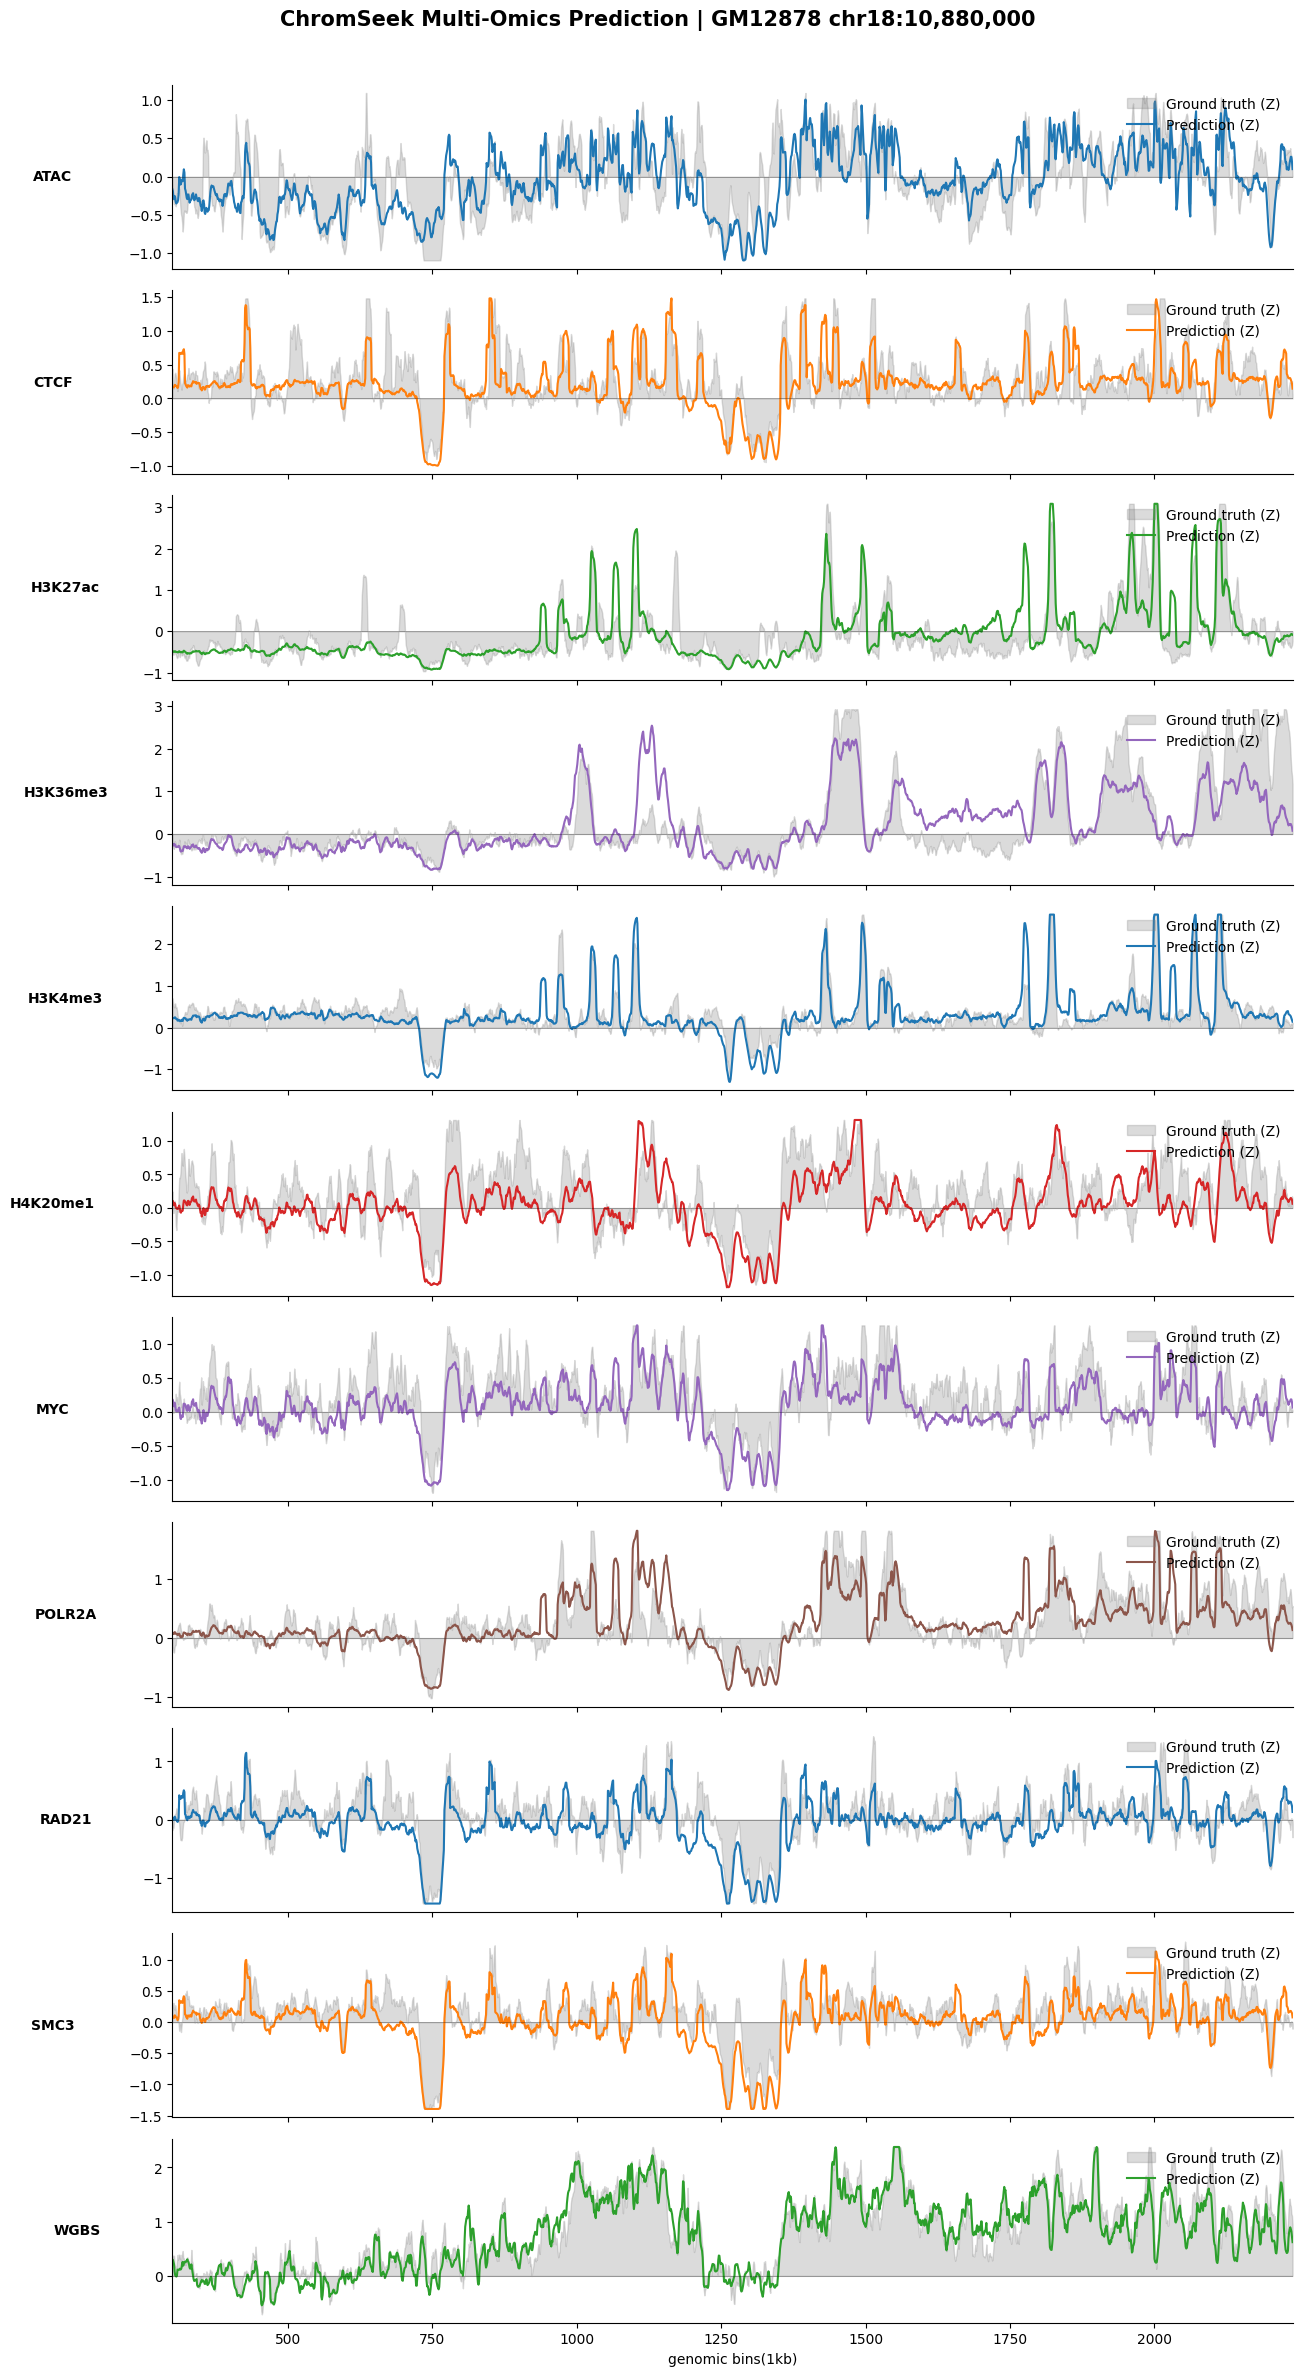

In [15]:
# ==========================================
# 7. Visualize Predicted Tracks
# ==========================================
if TRACKS_TO_PLOT is None:
    tracks_to_plot = track_order
else:
    unknown = sorted(set(TRACKS_TO_PLOT) - set(track_order))
    if unknown:
        raise ValueError(f'Unknown tracks: {unknown}')
    tracks_to_plot = TRACKS_TO_PLOT
tracks_to_plot = [track for track in tracks_to_plot if track not in OVERVIEW_EXCLUDED_TRACKS]
if not tracks_to_plot:
    raise ValueError('No tracks left to plot after applying OVERVIEW_EXCLUDED_TRACKS.')

def smooth(values, window):
    if window <= 1:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode='same')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
fig, axes = plt.subplots(len(tracks_to_plot), 1, figsize=(13, max(3, 2.2 * len(tracks_to_plot))), sharex=True)
axes = np.atleast_1d(axes)
x = np.arange(pred_z.shape[1])
display_start = max(0, int(DISPLAY_START_BIN))
display_end = min(int(DISPLAY_END_BIN), pred_z.shape[1])
if display_start >= display_end:
    raise ValueError(f'Invalid display bin interval: {DISPLAY_START_BIN}-{DISPLAY_END_BIN}')
display_slice = slice(display_start, display_end)
x_display = x[display_slice]
for ax, track in zip(axes, tracks_to_plot):
    idx = track_order.index(track)
    truth = smooth(target_z[idx], SMOOTH_WINDOW)[display_slice]
    prediction = smooth(pred_z[idx], SMOOTH_WINDOW)[display_slice]
    clip = max(np.percentile(np.abs(np.concatenate([truth, prediction])), 99), 1.0)
    ax.fill_between(x_display, np.clip(truth, -clip, clip), color='gray', alpha=0.28, label='Ground truth (Z)')
    ax.plot(x_display, np.clip(prediction, -clip, clip), color=colors[idx % len(colors)], linewidth=1.5, label='Prediction (Z)')
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_ylabel(track, rotation=0, labelpad=55, fontweight='bold', va='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper right', frameon=False)
axes[-1].set_xlim(display_start, display_end)
axes[-1].set_xlabel('genomic bins(1kb)')
plt.suptitle(f'ChromSeek Multi-Omics Prediction | {CELL_NAME} {chrom}:{start_bp:,}', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

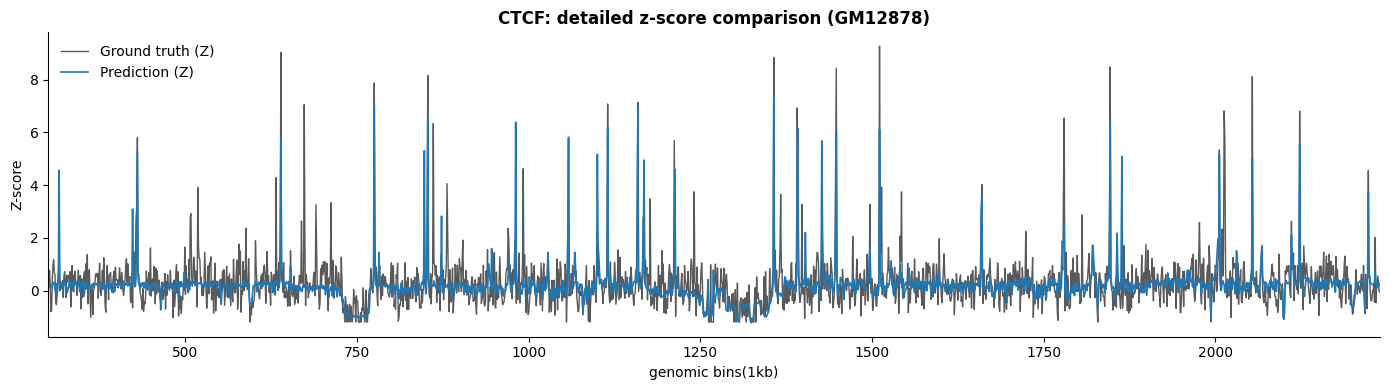

Workflow complete. Change TRACKS_TO_PLOT or DETAIL_TRACK and rerun the visualization cells.


In [16]:
# ==========================================
# 8. Compare a Selected Track in Detail (Optional)
# ==========================================
DETAIL_TRACK = 'CTCF' if 'CTCF' in track_order else track_order[0]
detail_idx = track_order.index(DETAIL_TRACK)
x = np.arange(pred_z.shape[1])
display_start = max(0, int(DISPLAY_START_BIN))
display_end = min(int(DISPLAY_END_BIN), pred_z.shape[1])
if display_start >= display_end:
    raise ValueError(f'Invalid display bin interval: {DISPLAY_START_BIN}-{DISPLAY_END_BIN}')
display_slice = slice(display_start, display_end)
x_display = x[display_slice]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x_display, target_z[detail_idx, display_slice], color='black', alpha=0.65, linewidth=1, label='Ground truth (Z)')
ax.plot(x_display, pred_z[detail_idx, display_slice], color='#1f77b4', linewidth=1.2, label='Prediction (Z)')
ax.set_title(f'{DETAIL_TRACK}: detailed z-score comparison ({CELL_NAME})', fontweight='bold')
ax.set_xlim(display_start, display_end)
ax.set_xlabel('genomic bins(1kb)')
ax.set_ylabel('Z-score')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print('Workflow complete. Change TRACKS_TO_PLOT or DETAIL_TRACK and rerun the visualization cells.')